## ***EDA Visualisation***

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# read the data
url=r'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
if url :
    try :
        dataframe=pd.read_csv(url)
        if dataframe is not None :
            print('Data read sucessfully')
        else :
            print('Failed to read data')
    except Exception as e:
        print(f'Data reading failed due to error : {e}')
else :
    print('Url not present')

Data read sucessfully


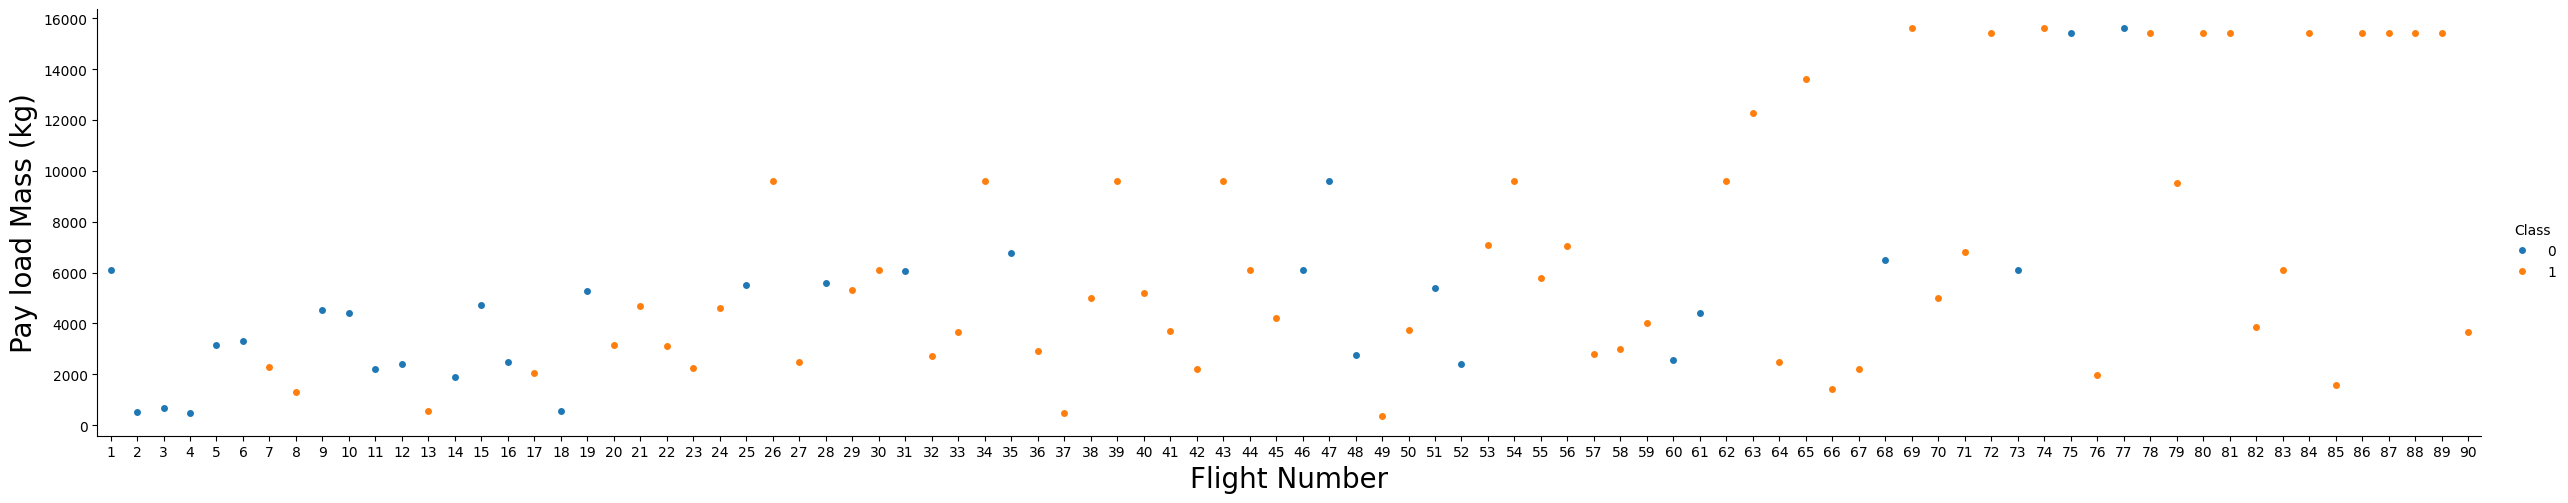

In [100]:
# flight number and payload mass 
sns.catplot(y='PayloadMass',x='FlightNumber',hue='Class',data=dataframe,aspect=5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

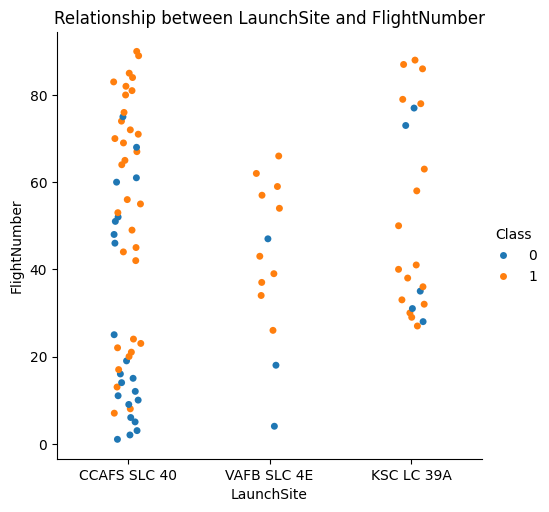

In [101]:
# relationship between flight number and launch site
sns.catplot(x='LaunchSite',y='FlightNumber',hue='Class',data=dataframe)
plt.title('Relationship between LaunchSite and FlightNumber')
plt.show()

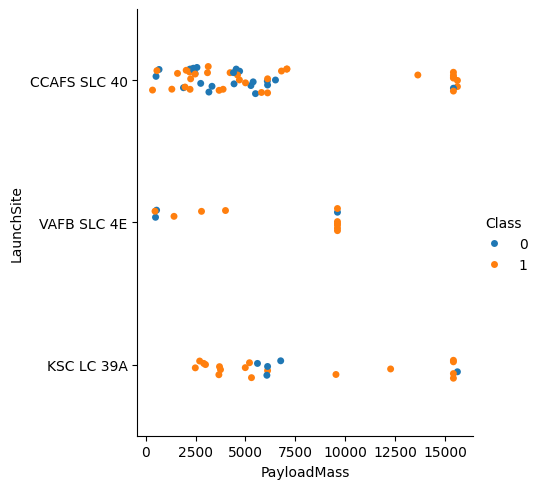

In [102]:
sns.catplot(x='PayloadMass',y='LaunchSite',data=dataframe,hue='Class')
plt.show()

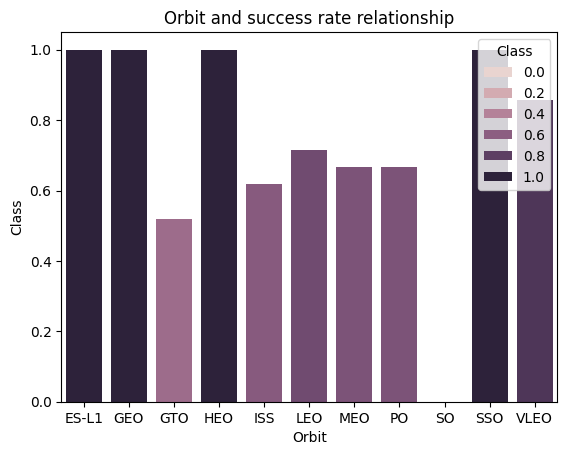

In [103]:
# success rate of each orbit 
data=dataframe.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x='Orbit',y='Class',hue='Class',data=data)
plt.title('Orbit and success rate relationship')
plt.show()


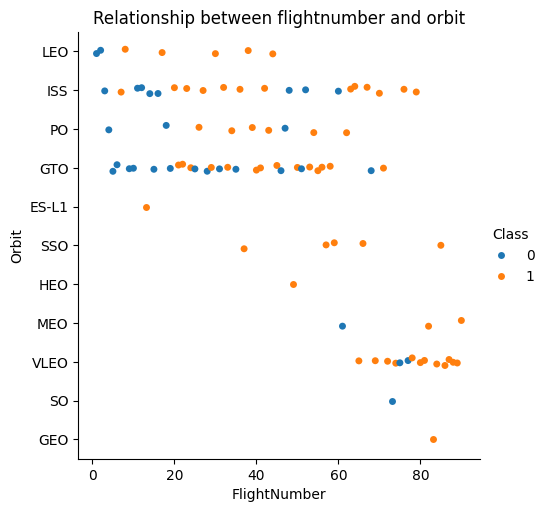

In [104]:
# relationship between flighnumber and orbit type
sns.catplot(x='FlightNumber',y='Orbit',hue='Class',data=dataframe) 
plt.title('Relationship between flightnumber and orbit')
plt.show()

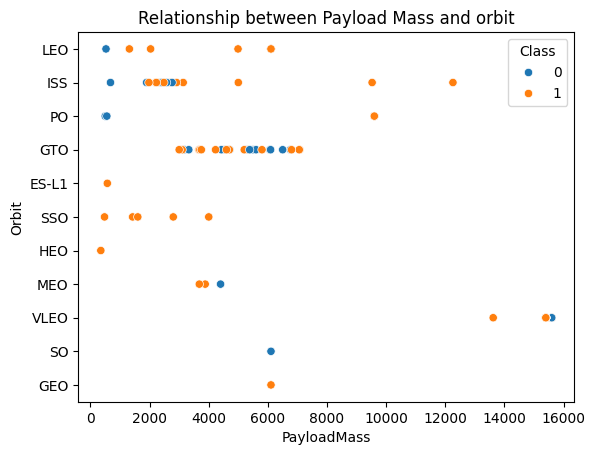

In [105]:
# relationship between payload mass and orbit
sns.scatterplot(x='PayloadMass',y='Orbit',hue='Class',data=dataframe) 
plt.title('Relationship between Payload Mass and orbit')
plt.show()

In [106]:
# extract year
year=[]
def extract():
    for i in dataframe['Date']:
        year.append(i.split('-')[0])
    return year
extract()
dataframe['Year']=year

In [107]:
dataframe.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013


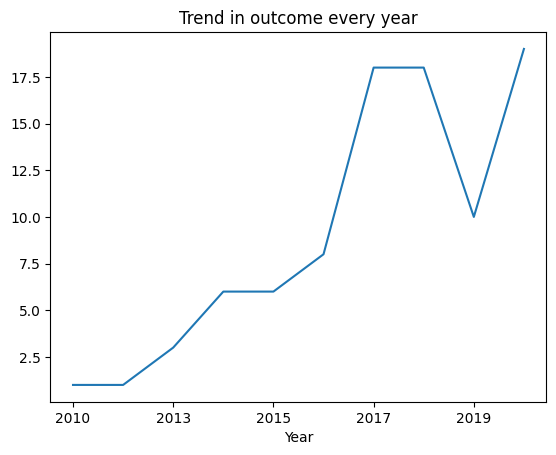

In [108]:
# line plot
data=dataframe.groupby('Year')['Outcome'].count()
data.plot(kind='line',x='Year',y='Outcome')
plt.title('Trend in outcome every year')
plt.show()
# sns.lineplot(x='Year',y='Outcome',data=dataframe)

In [109]:
# feature engineering
features = dataframe[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]

In [110]:
# categorical variables
cat_cols=features.select_dtypes(include=['object']).columns.to_list()
from sklearn.preprocessing import OneHotEncoder
encode=OneHotEncoder()
features_encoded=encode.fit_transform(features[cat_cols])

In [111]:
# get new features
feature_encoded_cols=pd.get_dummies(features[cat_cols])

In [112]:
# numerical cols
numerical_cols=features.select_dtypes(include=['number']).columns.to_list()
features[numerical_cols]=features[numerical_cols].astype('float64')

C:\Users\Mayank chouhan\AppData\Local\Temp\ipykernel_19316\1126923381.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[numerical_cols]=features[numerical_cols].astype('float64')


In [ ]:
features.drop(columns=cat_cols,inplace=True)

C:\Users\Mayank chouhan\AppData\Local\Temp\ipykernel_19316\4022325213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.drop(columns=cat_cols,inplace=True)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount
0,1.0,6104.959412,1.0,False,False,False,1.0,0.0
1,2.0,525.000000,1.0,False,False,False,1.0,0.0
2,3.0,677.000000,1.0,False,False,False,1.0,0.0
3,4.0,500.000000,1.0,False,False,False,1.0,0.0
4,5.0,3170.000000,1.0,False,False,False,1.0,0.0
...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,True,True,True,5.0,2.0
86,87.0,15400.000000,3.0,True,True,True,5.0,2.0
87,88.0,15400.000000,6.0,True,True,True,5.0,5.0
88,89.0,15400.000000,3.0,True,True,True,5.0,2.0


In [119]:
feature_encoded_cols.columns

Index(['Orbit_ES-L1', 'Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS',
       'Orbit_LEO', 'Orbit_MEO', 'Orbit_PO', 'Orbit_SO', 'Orbit_SSO',
       'Orbit_VLEO', 'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A',
       'LaunchSite_VAFB SLC 4E', 'LandingPad_5e9e3032383ecb267a34e7c7',
       'LandingPad_5e9e3032383ecb554034e7c9',
       'LandingPad_5e9e3032383ecb6bb234e7ca',
       'LandingPad_5e9e3032383ecb761634e7cb',
       'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005',
       'Serial_B0007', 'Serial_B1003', 'Serial_B1004', 'Serial_B1005',
       'Serial_B1006', 'Serial_B1007', 'Serial_B1008', 'Serial_B1010',
       'Serial_B1011', 'Serial_B1012', 'Serial_B1013', 'Serial_B1015',
       'Serial_B1016', 'Serial_B1017', 'Serial_B1018', 'Serial_B1019',
       'Serial_B1020', 'Serial_B1021', 'Serial_B1022', 'Serial_B1023',
       'Serial_B1025', 'Serial_B1026', 'Serial_B1028', 'Serial_B1029',
       'Serial_B1030', 'Serial_B1031', 'Serial_B1032', 'Serial_B1034'

In [125]:
#cincat features
feature=pd.concat([features,feature_encoded_cols])
feature.to_csv('features_encoded.csv',index=False)